# MRC Volume Reconstruction Analysis

Compare the new `volume{file_idx}_rec.mrc` reconstructions against the saved iterative diffusion baseline, the saved limited-angle Fourier/FBP baseline, and the matching `gt_fbp_{file_idx}.npy` ground truth. The MRC volume is evaluated twice: once after axis alignment plus rotate-batch correction, and once after Fourier-wedge inpainting guidance.

Metrics use the normalization sidecar range from `la_fourier_{file_idx}_norm.json`:

```python
data_range = norm_max - norm_min
```

By default, the circular support mask is applied before metrics to match the evaluation path used by `test_large_ladiff_conditional.ipynb` and `reconstruct_ladiff_slices.py`. Set `APPLY_CIRCLE_MASK = False` in the configuration cell to evaluate the raw `gt_fbp_np` arrays directly.


## 1. Imports and Configuration


In [ ]:
from pathlib import Path
import csv
import itertools
import json
import math
import re
import struct
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

project_root = Path('/myhome/sdate')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from ladiff.fourier_wedge import apply_circle_mask as torch_apply_circle_mask
from ladiff.recon_utils import inpaint_guidance as _inpaint_guidance

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

DATA_ROOT = Path('/myhome/data/sdate/shared/compression_paper')
MRC_PATTERN = 'volume*_rec.mrc'

# Set to a list such as [1, 10] to force specific files, or None to auto-discover.
FILE_IDXS = None

# Matches the downstream evaluation in test_large_ladiff_conditional.ipynb after Section 3.
# Set False to compare against raw gt_fbp_np without the circular support mask.
APPLY_CIRCLE_MASK = True

# MRC orientation correction applied after aligning MRC axes to the GT numpy shape.
ANGLE_CORRECTION_DEG = -36

# Fourier inpainting guidance geometry, matching test_large_ladiff_conditional.ipynb.
ANGULAR_RANGE_FRAC = 0.6
ANGULAR_RANGE_DEG = int(ANGULAR_RANGE_FRAC * 180)
START_ANGLE = (180 - ANGULAR_RANGE_DEG) // 2
TILT_AXIS = 0

# Full-volume FFTs are memory-heavy; use CUDA when available, otherwise fall back to CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_MRC_INPAINTING = False
INPAINT_TIMESTEP = 0
INPAINT_STEPS = 1

# The test notebook averaged the guided batch over slices for synthetic repeated-slice tests.
# Keep this False for real 3D volume evaluation so the volume is not collapsed to one repeated slice.
AVERAGE_INPAINT_SLICES = False

# Per-slice metric records can be large if more volumes are added. They are useful for plots and debugging.
KEEP_SLICE_RECORDS = True

OUTPUT_CSV = DATA_ROOT / 'mrc_vs_diffusion_volume_metrics.csv'
print(f'Data root: {DATA_ROOT}')
print(f'Inpainting device: {device}')


Data root: /myhome/data/sdate/shared/compression_paper
Inpainting device: cuda


## 2. Helpers


In [14]:
def file_idx_from_mrc(path):
    match = re.search(r'volume(\d+)_rec\.mrc$', path.name)
    if not match:
        raise ValueError(f'Could not parse file_idx from {path}')
    return int(match.group(1))


def mrc_memmap(path):
    """Read common MRC files as a numpy memmap with shape (nz, ny, nx)."""
    path = Path(path)
    dtype_by_mode = {
        0: 'i1',   # signed 8-bit integer
        1: 'i2',   # signed 16-bit integer
        2: 'f4',   # float32
        6: 'u2',   # unsigned 16-bit integer
        12: 'f2',  # float16
    }

    with path.open('rb') as f:
        header = f.read(1024)
    if len(header) != 1024:
        raise ValueError(f'{path} is too small to be an MRC file')

    parsed = None
    for endian in ('<', '>'):
        nx, ny, nz, mode = struct.unpack(endian + '4i', header[:16])
        if nx > 0 and ny > 0 and nz > 0 and mode in dtype_by_mode:
            nsymbt = struct.unpack(endian + 'i', header[92:96])[0]
            mapc, mapr, maps = struct.unpack(endian + '3i', header[64:76])
            parsed = {
                'nx': nx,
                'ny': ny,
                'nz': nz,
                'mode': mode,
                'nsymbt': max(nsymbt, 0),
                'mapc': mapc,
                'mapr': mapr,
                'maps': maps,
                'endian': endian,
            }
            break
    if parsed is None:
        raise ValueError(f'Could not parse MRC header for {path}')

    dtype = np.dtype(dtype_by_mode[parsed['mode']]).newbyteorder(parsed['endian'])
    offset = 1024 + parsed['nsymbt']
    shape = (parsed['nz'], parsed['ny'], parsed['nx'])
    arr = np.memmap(path, dtype=dtype, mode='r', offset=offset, shape=shape, order='C')
    return arr, parsed


def align_volume_to_gt(volume, gt_shape):
    """Return a view of volume whose axes match gt_shape, trying all 3D permutations."""
    if tuple(volume.shape) == tuple(gt_shape):
        return volume, 'as_read'

    for perm in itertools.permutations(range(3)):
        if tuple(volume.shape[i] for i in perm) == tuple(gt_shape):
            return np.transpose(volume, perm), f'transpose{perm}'

    raise ValueError(f'Cannot align volume shape {volume.shape} to GT shape {gt_shape}')


def circle_mask_2d(shape):
    h, w = shape
    yy, xx = np.ogrid[:h, :w]
    cy = (h - 1) / 2.0
    cx = (w - 1) / 2.0
    radius = min(h, w) / 2.0
    return ((yy - cy) ** 2 + (xx - cx) ** 2) <= radius ** 2


def apply_optional_mask(image, mask):
    if mask is None:
        return np.asarray(image, dtype=np.float32)
    return np.where(mask, image, 0).astype(np.float32, copy=False)


def psnr_from_mse(mse, data_range):
    if mse == 0:
        return float('inf')
    return 10.0 * math.log10((data_range ** 2) / mse)


def summarize(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        'mean': float(np.mean(arr)),
        'std': float(np.std(arr)),
        'min': float(np.min(arr)),
        'max': float(np.max(arr)),
    }


def compute_volume_metrics(gt, recon, data_range, mask=None, desc=''):
    if gt.shape != recon.shape:
        raise ValueError(f'Shape mismatch: GT {gt.shape}, recon {recon.shape}')

    per_slice = []
    sse = 0.0
    count = 0
    iterator = tqdm(range(gt.shape[0]), desc=desc, leave=False)

    for slice_idx in iterator:
        gt_slice = apply_optional_mask(gt[slice_idx], mask)
        recon_slice = apply_optional_mask(recon[slice_idx], mask)

        if not np.isfinite(gt_slice).all() or not np.isfinite(recon_slice).all():
            warnings.warn(f'Non-finite values found in {desc}, slice {slice_idx}; replacing with zeros.')
            gt_slice = np.nan_to_num(gt_slice, copy=False)
            recon_slice = np.nan_to_num(recon_slice, copy=False)

        err = gt_slice.astype(np.float64) - recon_slice.astype(np.float64)
        slice_sse = float(np.sum(err * err))
        slice_mse = slice_sse / err.size
        sse += slice_sse
        count += err.size

        per_slice.append({
            'slice': slice_idx,
            'psnr': psnr_from_mse(slice_mse, data_range),
            'ssim': float(compute_ssim(gt_slice, recon_slice, data_range=data_range)),
        })

    volume_mse = sse / count
    psnr_stats = summarize([x['psnr'] for x in per_slice])
    ssim_stats = summarize([x['ssim'] for x in per_slice])

    return {
        'volume_mse': volume_mse,
        'volume_psnr': psnr_from_mse(volume_mse, data_range),
        'mean_slice_psnr': psnr_stats['mean'],
        'std_slice_psnr': psnr_stats['std'],
        'min_slice_psnr': psnr_stats['min'],
        'max_slice_psnr': psnr_stats['max'],
        'mean_slice_ssim': ssim_stats['mean'],
        'std_slice_ssim': ssim_stats['std'],
        'min_slice_ssim': ssim_stats['min'],
        'max_slice_ssim': ssim_stats['max'],
        'per_slice': per_slice,
    }


def records_to_markdown(records, columns):
    if not records:
        return '_No records._'

    def fmt(value):
        if isinstance(value, float):
            if math.isinf(value):
                return 'inf'
            return f'{value:.6g}'
        return str(value)

    header = '| ' + ' | '.join(columns) + ' |'
    sep = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    rows = []
    for record in records:
        rows.append('| ' + ' | '.join(fmt(record.get(col, '')) for col in columns) + ' |')
    return '\n'.join([header, sep] + rows)


## 3. Discover Matched Volumes


In [15]:
all_mrc_paths = sorted(DATA_ROOT.rglob(MRC_PATTERN), key=lambda p: file_idx_from_mrc(p))
if FILE_IDXS is not None:
    wanted = set(FILE_IDXS)
    all_mrc_paths = [p for p in all_mrc_paths if file_idx_from_mrc(p) in wanted]

cases = []
missing = []
for mrc_path in all_mrc_paths:
    file_idx = file_idx_from_mrc(mrc_path)
    recon_dir = DATA_ROOT / f'file_{file_idx}_extracted' / 'reconstruction'
    diffusion_path = recon_dir / f'diffusion_{file_idx}_iterative.npy'
    gt_path = recon_dir / f'gt_fbp_{file_idx}.npy'
    norm_path = recon_dir / f'la_fourier_{file_idx}_norm.json'
    la_fourier_path = recon_dir / f'la_fourier_{file_idx}.npy'

    required = {
        'mrc': mrc_path,
        'diffusion': diffusion_path,
        'gt': gt_path,
        'norm': norm_path,
        'la_fourier': la_fourier_path,
    }
    absent = [name for name, path in required.items() if not path.exists()]
    if absent:
        missing.append({'file_idx': file_idx, 'missing': ', '.join(absent)})
        continue

    cases.append({
        'file_idx': file_idx,
        'mrc_path': mrc_path,
        'diffusion_path': diffusion_path,
        'gt_path': gt_path,
        'norm_path': norm_path,
        'la_fourier_path': la_fourier_path,
    })

print(f'Found {len(cases)} complete matched case(s).')
display(Markdown(records_to_markdown(cases, ['file_idx', 'mrc_path', 'diffusion_path', 'la_fourier_path', 'gt_path', 'norm_path'])))
if missing:
    display(Markdown('### Missing inputs\n' + records_to_markdown(missing, ['file_idx', 'missing'])))


Found 2 complete matched case(s).


| file_idx | mrc_path | diffusion_path | la_fourier_path | gt_path | norm_path |
| --- | --- | --- | --- | --- | --- |
| 1 | /myhome/data/sdate/shared/compression_paper/ISONET/volume1_rec.mrc | /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/diffusion_1_iterative.npy | /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fourier_1.npy | /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/gt_fbp_1.npy | /myhome/data/sdate/shared/compression_paper/file_1_extracted/reconstruction/la_fourier_1_norm.json |
| 10 | /myhome/data/sdate/shared/compression_paper/ISONET/volume10_rec.mrc | /myhome/data/sdate/shared/compression_paper/file_10_extracted/reconstruction/diffusion_10_iterative.npy | /myhome/data/sdate/shared/compression_paper/file_10_extracted/reconstruction/la_fourier_10.npy | /myhome/data/sdate/shared/compression_paper/file_10_extracted/reconstruction/gt_fbp_10.npy | /myhome/data/sdate/shared/compression_paper/file_10_extracted/reconstruction/la_fourier_10_norm.json |

## 4. Compute Metrics


In [16]:
from scipy.ndimage import rotate


def rotate_batch(x: np.ndarray, alpha: float, desc: str = 'rotate_batch') -> np.ndarray:
    """Rotate a batch of 2D images with shape (D, H, W) by alpha degrees."""
    x = np.asarray(x, dtype=np.float32)
    if alpha is None or abs(float(alpha)) < 1e-12:
        return x

    out = np.empty_like(x, dtype=np.float32)
    for i in tqdm(range(x.shape[0]), desc=desc, leave=False):
        out[i] = rotate(
            x[i],
            angle=float(alpha),
            reshape=False,
            order=1,
            mode='constant',
            cval=0.0,
            prefilter=False,
        ).astype(np.float32, copy=False)
    return out


def inpaint_guidance(
    source_volume: torch.Tensor,
    vol_init: torch.Tensor,
    timestep: int = 0,
    inpaint_steps: int = 1,
) -> torch.Tensor:
    """Thin wrapper that passes notebook-local geometry params to recon_utils."""
    with torch.no_grad():
        x = _inpaint_guidance(
            source_volume=source_volume,
            vol_init=vol_init,
            angular_range_deg=ANGULAR_RANGE_DEG,
            start_angle=START_ANGLE,
            tilt_axis=TILT_AXIS,
            device=device,
            timestep=timestep,
            inpaint_steps=inpaint_steps,
        )
        if AVERAGE_INPAINT_SLICES:
            x = torch.mean(x, dim=0, keepdim=True).repeat(x.shape[0], 1, 1)
    return x


def inpaint_reconstruction_volume(source_np: np.ndarray, recon_np: np.ndarray, desc: str = 'mrc inpainting') -> np.ndarray:
    """Apply Fourier-wedge inpainting guidance to a full 3D reconstruction volume."""
    print(f'{desc}: moving volumes to {device} and applying Fourier inpainting guidance')
    source = torch.as_tensor(np.asarray(source_np, dtype=np.float32), device=device)
    recon = torch.as_tensor(np.asarray(recon_np, dtype=np.float32), device=device)

    if APPLY_CIRCLE_MASK:
        source = torch_apply_circle_mask(source)
        recon = torch_apply_circle_mask(recon)

    guided = inpaint_guidance(
        source_volume=source,
        vol_init=recon,
        timestep=INPAINT_TIMESTEP,
        inpaint_steps=INPAINT_STEPS,
    )
    guided_np = guided.detach().cpu().numpy().astype(np.float32, copy=False)

    del source, recon, guided
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return guided_np


In [17]:
print(
    f'Geometry: angular_range={ANGULAR_RANGE_DEG} deg, start={START_ANGLE} deg, tilt_axis={TILT_AXIS}'
)
print(f'MRC rotate_batch angle correction: {ANGLE_CORRECTION_DEG} deg')
print(f'Run MRC inpainting: {RUN_MRC_INPAINTING}, average slices: {AVERAGE_INPAINT_SLICES}')


Geometry: angular_range=108 deg, start=36 deg, tilt_axis=0
MRC rotate_batch angle correction: -36 deg
Run MRC inpainting: True, average slices: False


In [18]:
summary_records = []
slice_records = []
loaded_cases = []

for case in cases:
    file_idx = case['file_idx']
    print(f'\n=== file_idx {file_idx} ===')

    gt = np.load(case['gt_path'], mmap_mode='r')
    diffusion = np.load(case['diffusion_path'], mmap_mode='r')
    la_fourier = np.load(case['la_fourier_path'], mmap_mode='r')
    mrc_raw, mrc_meta = mrc_memmap(case['mrc_path'])
    mrc_aligned, mrc_alignment = align_volume_to_gt(mrc_raw, gt.shape)
    mrc_rotated = rotate_batch(
        mrc_aligned,
        ANGLE_CORRECTION_DEG,
        desc=f'{file_idx} mrc rotate {ANGLE_CORRECTION_DEG} deg',
    )

    if diffusion.shape != gt.shape:
        raise ValueError(f'Diffusion shape {diffusion.shape} does not match GT shape {gt.shape}')
    if la_fourier.shape != gt.shape:
        raise ValueError(f'LA Fourier shape {la_fourier.shape} does not match GT shape {gt.shape}')

    with open(case['norm_path']) as f:
        norm_cfg = json.load(f)
    norm_min = float(norm_cfg['norm_min'])
    norm_max = float(norm_cfg['norm_max'])
    data_range = norm_max - norm_min

    mask = circle_mask_2d(gt.shape[-2:]) if APPLY_CIRCLE_MASK else None

    print(f'GT shape:        {gt.shape}, dtype={gt.dtype}')
    print(f'Diffusion shape: {diffusion.shape}, dtype={diffusion.dtype}')
    print(f'LA Fourier shape:{la_fourier.shape}, dtype={la_fourier.dtype}')
    print(f'MRC raw shape:   {mrc_raw.shape}, dtype={mrc_raw.dtype}, alignment={mrc_alignment}')
    print(f'norm_min={norm_min:.8g}, norm_max={norm_max:.8g}, data_range={data_range:.8g}')
    print(f'circle mask: {APPLY_CIRCLE_MASK}')

    methods = {
        'la_fourier': la_fourier,
        'diffusion_iterative': diffusion,
        'mrc_volume_rec': mrc_rotated,
    }

    if RUN_MRC_INPAINTING:
        methods['mrc_volume_rec_inpainted'] = inpaint_reconstruction_volume(
            source_np=gt,
            recon_np=mrc_rotated,
            desc=f'{file_idx} mrc_volume_rec_inpainted',
        )

    loaded_cases.append({
        **case,
        'gt': gt,
        'methods': methods,
        'norm_min': norm_min,
        'norm_max': norm_max,
        'data_range': data_range,
        'mask': mask,
        'mrc_meta': mrc_meta,
        'mrc_alignment': mrc_alignment,
        'angle_correction_deg': ANGLE_CORRECTION_DEG,
    })

    for method, recon in methods.items():
        metrics = compute_volume_metrics(gt, recon, data_range, mask=mask, desc=f'{file_idx} {method}')
        is_mrc = method.startswith('mrc_volume_rec')
        is_inpainted = method.endswith('_inpainted')
        record = {
            'file_idx': file_idx,
            'method': method,
            'shape': 'x'.join(map(str, gt.shape)),
            'data_range': data_range,
            'norm_min': norm_min,
            'norm_max': norm_max,
            'circle_mask': APPLY_CIRCLE_MASK,
            'angle_correction_deg': ANGLE_CORRECTION_DEG if is_mrc else '',
            'inpainted': is_inpainted,
            'angular_range_deg': ANGULAR_RANGE_DEG if is_inpainted else '',
            'start_angle': START_ANGLE if is_inpainted else '',
            'tilt_axis': TILT_AXIS if is_inpainted else '',
            'volume_psnr': metrics['volume_psnr'],
            'mean_slice_psnr': metrics['mean_slice_psnr'],
            'std_slice_psnr': metrics['std_slice_psnr'],
            'mean_slice_ssim': metrics['mean_slice_ssim'],
            'std_slice_ssim': metrics['std_slice_ssim'],
            'min_slice_psnr': metrics['min_slice_psnr'],
            'max_slice_psnr': metrics['max_slice_psnr'],
            'min_slice_ssim': metrics['min_slice_ssim'],
            'max_slice_ssim': metrics['max_slice_ssim'],
            'mrc_alignment': mrc_alignment if is_mrc else '',
        }
        summary_records.append(record)

        if KEEP_SLICE_RECORDS:
            for row in metrics['per_slice']:
                slice_records.append({
                    'file_idx': file_idx,
                    'method': method,
                    'slice': row['slice'],
                    'psnr': row['psnr'],
                    'ssim': row['ssim'],
                })

summary_columns = [
    'file_idx', 'method', 'shape', 'data_range', 'circle_mask',
    'angle_correction_deg', 'inpainted', 'angular_range_deg', 'start_angle', 'tilt_axis',
    'volume_psnr', 'mean_slice_psnr', 'std_slice_psnr',
    'mean_slice_ssim', 'std_slice_ssim', 'mrc_alignment',
]
display(Markdown(records_to_markdown(summary_records, summary_columns)))



=== file_idx 1 ===


GT shape:        (540, 640, 640), dtype=float32
Diffusion shape: (540, 640, 640), dtype=float32
LA Fourier shape:(540, 640, 640), dtype=float32
MRC raw shape:   (640, 540, 640), dtype=float32, alignment=transpose(1, 0, 2)
norm_min=-0.00079530105, norm_max=0.0032794406, data_range=0.0040747416
circle mask: True
1 mrc_volume_rec_inpainted: moving volumes to cuda and applying Fourier inpainting guidance



=== file_idx 10 ===


GT shape:        (440, 640, 640), dtype=float32
Diffusion shape: (440, 640, 640), dtype=float32
LA Fourier shape:(440, 640, 640), dtype=float32
MRC raw shape:   (640, 440, 640), dtype=float32, alignment=transpose(1, 0, 2)
norm_min=-0.0025180832, norm_max=0.0066690706, data_range=0.0091871538
circle mask: True
10 mrc_volume_rec_inpainted: moving volumes to cuda and applying Fourier inpainting guidance


| file_idx | method | shape | data_range | circle_mask | angle_correction_deg | inpainted | angular_range_deg | start_angle | tilt_axis | volume_psnr | mean_slice_psnr | std_slice_psnr | mean_slice_ssim | std_slice_ssim | mrc_alignment |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | la_fourier | 540x640x640 | 0.00407474 | True |  | False |  |  |  | 19.5947 | 19.9451 | 1.98082 | 0.661117 | 0.0678783 |  |
| 1 | diffusion_iterative | 540x640x640 | 0.00407474 | True |  | False |  |  |  | 19.3632 | 20.1216 | 2.92248 | 0.548916 | 0.0990462 |  |
| 1 | mrc_volume_rec | 540x640x640 | 0.00407474 | True | -36 | False |  |  |  | 13.6002 | 13.7175 | 1.01407 | 0.46878 | 0.032196 | transpose(1, 0, 2) |
| 1 | mrc_volume_rec_inpainted | 540x640x640 | 0.00407474 | True | -36 | True | 108 | 36 | 0 | 17.0201 | 17.232 | 1.34135 | 0.646064 | 0.0548105 | transpose(1, 0, 2) |
| 10 | la_fourier | 440x640x640 | 0.00918715 | True |  | False |  |  |  | 18.308 | 18.3135 | 0.217583 | 0.704757 | 0.0101198 |  |
| 10 | diffusion_iterative | 440x640x640 | 0.00918715 | True |  | False |  |  |  | 19.7581 | 19.7672 | 0.281175 | 0.711193 | 0.0190875 |  |
| 10 | mrc_volume_rec | 440x640x640 | 0.00918715 | True | -36 | False |  |  |  | 19.0519 | 19.0678 | 0.369517 | 0.590811 | 0.010198 | transpose(1, 0, 2) |
| 10 | mrc_volume_rec_inpainted | 440x640x640 | 0.00918715 | True | -36 | True | 108 | 36 | 0 | 20.0523 | 20.0616 | 0.281592 | 0.785873 | 0.00916141 | transpose(1, 0, 2) |

## 5. Save Summary Table


In [19]:
if summary_records:
    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    with OUTPUT_CSV.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(summary_records[0].keys()))
        writer.writeheader()
        writer.writerows(summary_records)
    print(f'Wrote {OUTPUT_CSV}')
else:
    print('No summary records to save.')


Wrote /myhome/data/sdate/shared/compression_paper/mrc_vs_diffusion_volume_metrics.csv


## 6. Metric Plots


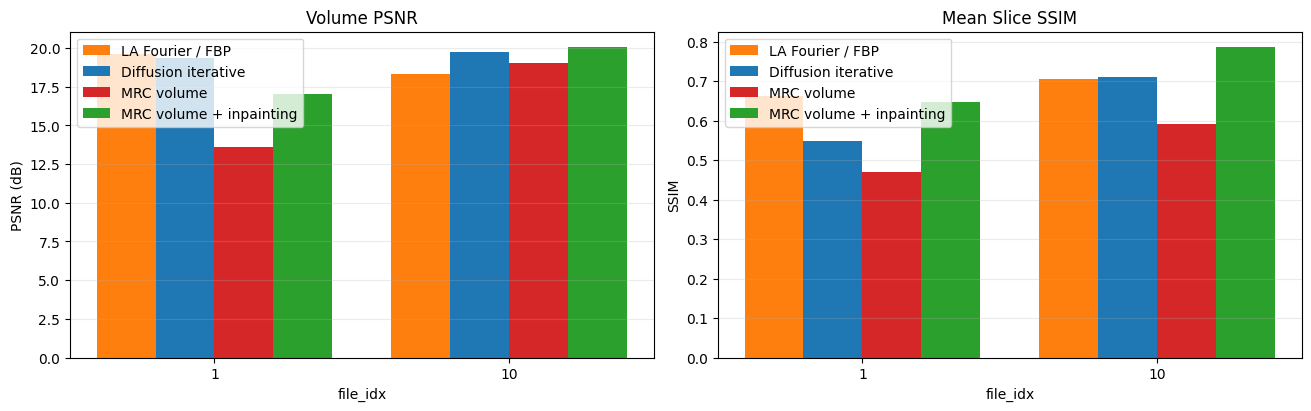

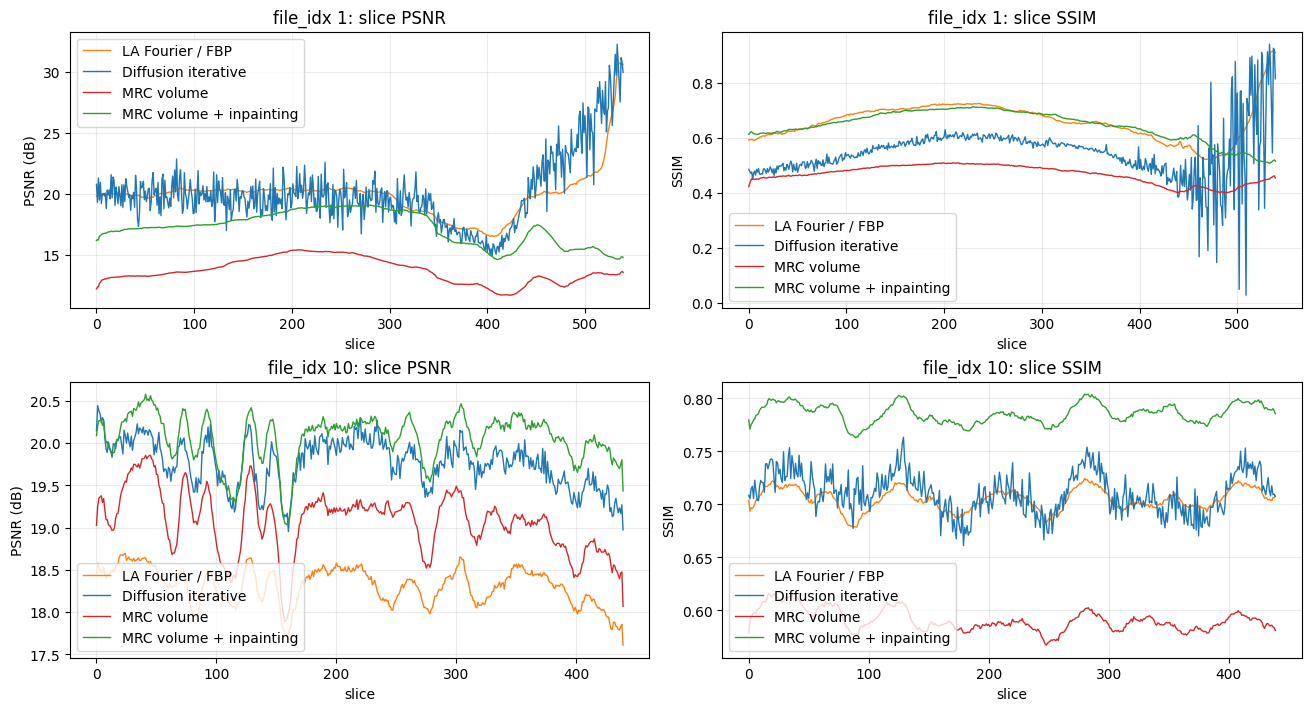

In [20]:
METHOD_ORDER = ['la_fourier', 'diffusion_iterative', 'mrc_volume_rec', 'mrc_volume_rec_inpainted']
METHOD_LABELS = {
    'la_fourier': 'LA Fourier / FBP',
    'diffusion_iterative': 'Diffusion iterative',
    'mrc_volume_rec': 'MRC volume',
    'mrc_volume_rec_inpainted': 'MRC volume + inpainting',
}
METHOD_COLORS = {
    'la_fourier': 'C1',
    'diffusion_iterative': 'C0',
    'mrc_volume_rec': 'C3',
    'mrc_volume_rec_inpainted': 'C2',
}

if summary_records:
    file_ids = sorted({r['file_idx'] for r in summary_records})
    methods = [m for m in METHOD_ORDER if any(r['method'] == m for r in summary_records)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
    width = min(0.8 / max(len(methods), 1), 0.28)
    x = np.arange(len(file_ids))
    offsets = (np.arange(len(methods)) - (len(methods) - 1) / 2) * width

    for offset, method in zip(offsets, methods):
        rows = [next(r for r in summary_records if r['file_idx'] == fid and r['method'] == method) for fid in file_ids]
        axes[0].bar(x + offset, [r['volume_psnr'] for r in rows], width, label=METHOD_LABELS[method], color=METHOD_COLORS[method])
        axes[1].bar(x + offset, [r['mean_slice_ssim'] for r in rows], width, label=METHOD_LABELS[method], color=METHOD_COLORS[method])

    axes[0].set_title('Volume PSNR')
    axes[0].set_ylabel('PSNR (dB)')
    axes[1].set_title('Mean Slice SSIM')
    axes[1].set_ylabel('SSIM')

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels([str(fid) for fid in file_ids])
        ax.set_xlabel('file_idx')
        ax.grid(axis='y', alpha=0.25)
        ax.legend()

    plt.show()

if slice_records:
    file_ids = sorted({r['file_idx'] for r in slice_records})
    methods = [m for m in METHOD_ORDER if any(r['method'] == m for r in slice_records)]
    fig, axes = plt.subplots(len(file_ids), 2, figsize=(13, 3.5 * len(file_ids)), squeeze=False, constrained_layout=True)

    for row_idx, fid in enumerate(file_ids):
        for method in methods:
            rows = [r for r in slice_records if r['file_idx'] == fid and r['method'] == method]
            rows.sort(key=lambda r: r['slice'])
            axes[row_idx, 0].plot([r['slice'] for r in rows], [r['psnr'] for r in rows], color=METHOD_COLORS[method], label=METHOD_LABELS[method], linewidth=1)
            axes[row_idx, 1].plot([r['slice'] for r in rows], [r['ssim'] for r in rows], color=METHOD_COLORS[method], label=METHOD_LABELS[method], linewidth=1)

        axes[row_idx, 0].set_title(f'file_idx {fid}: slice PSNR')
        axes[row_idx, 0].set_ylabel('PSNR (dB)')
        axes[row_idx, 1].set_title(f'file_idx {fid}: slice SSIM')
        axes[row_idx, 1].set_ylabel('SSIM')
        for ax in axes[row_idx]:
            ax.set_xlabel('slice')
            ax.grid(alpha=0.25)
            ax.legend()

    plt.show()


## 7. Middle-Slice Visual Checks


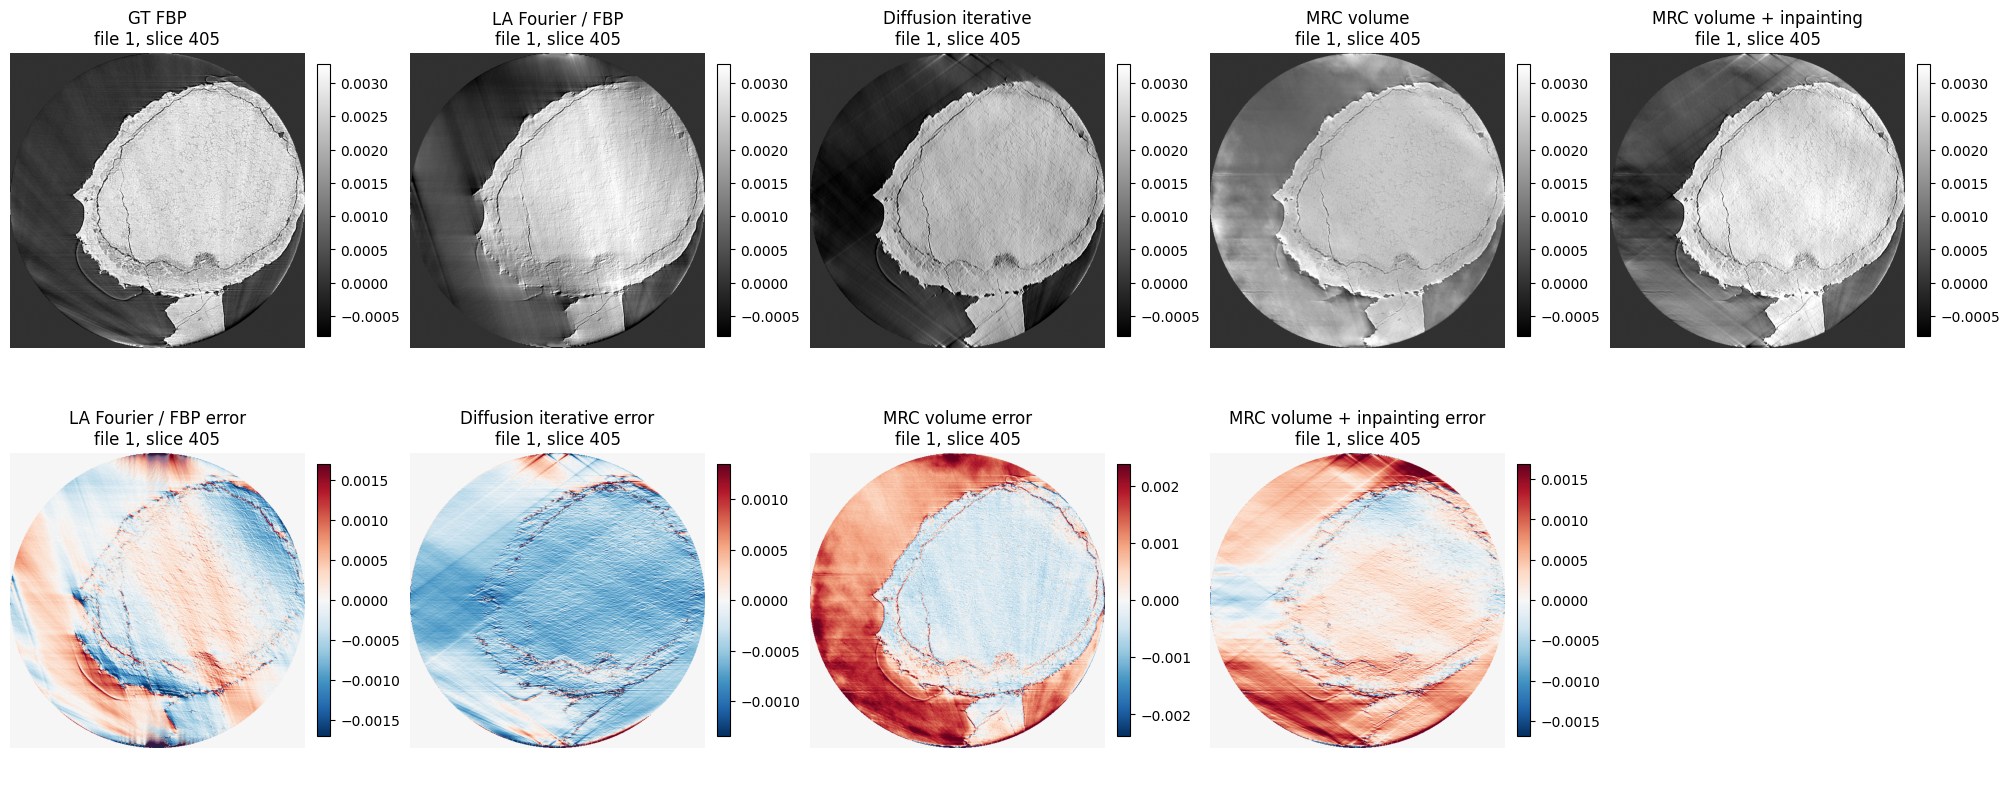

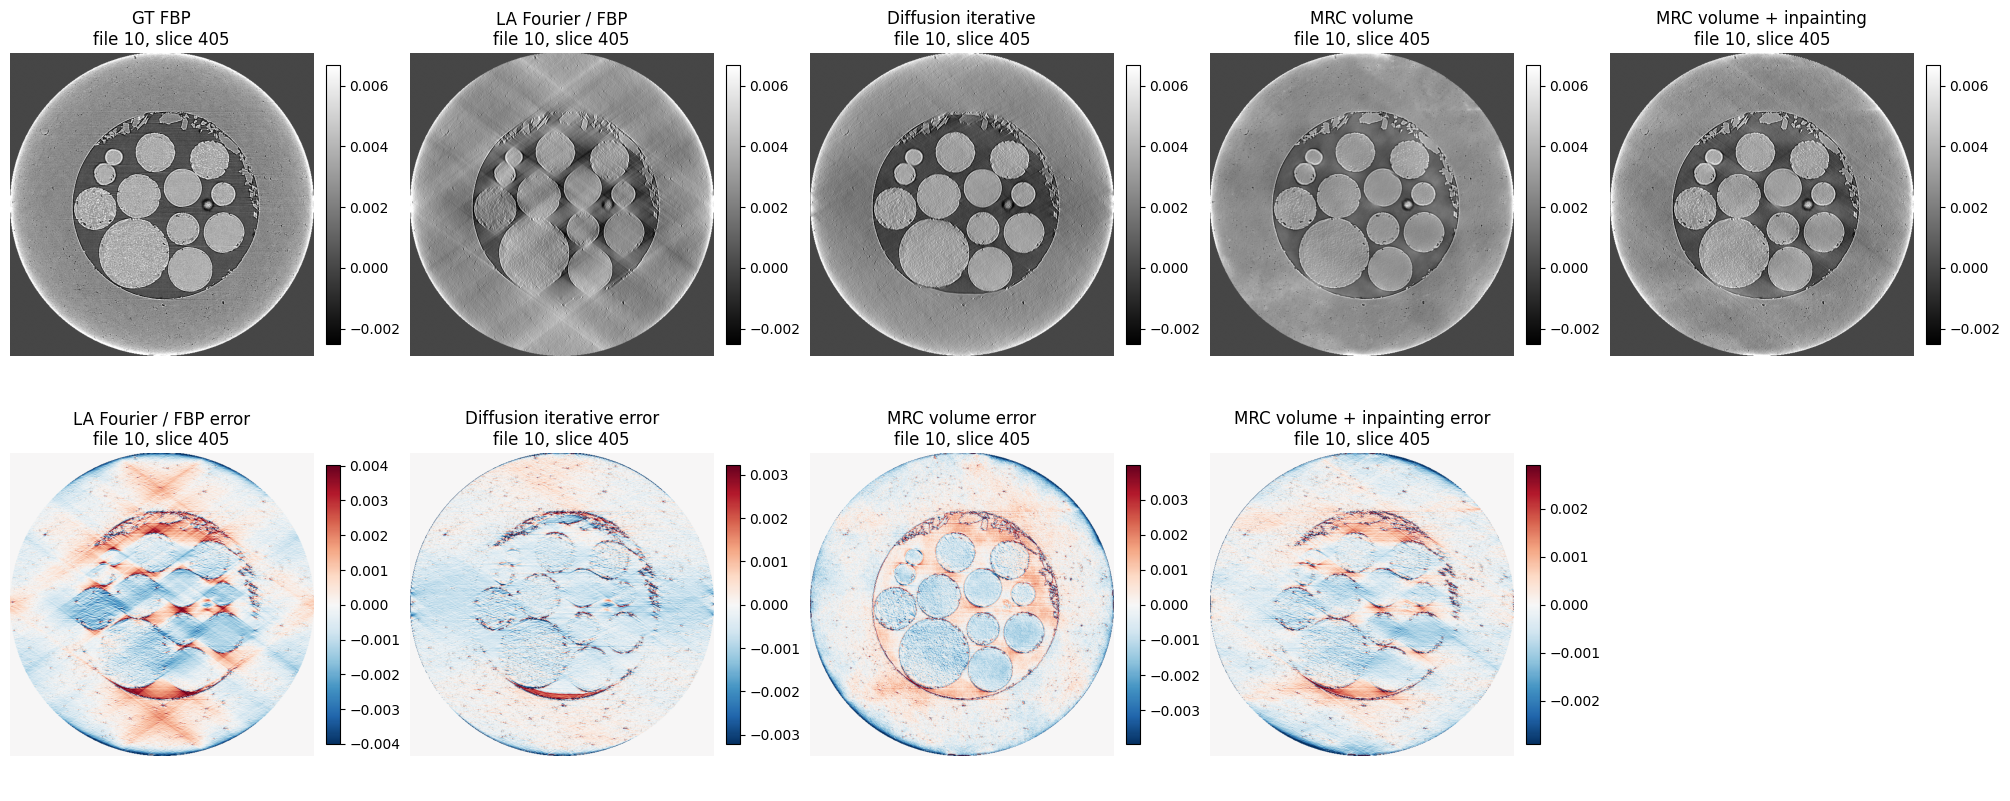

In [21]:
mid = 405
for case in loaded_cases:
    fid = case['file_idx']
    gt = case['gt']
    mask = case['mask']
    vmin = case['norm_min']
    vmax = case['norm_max']

    method_names = [m for m in METHOD_ORDER if m in case['methods']]
    gt_mid = apply_optional_mask(gt[mid], mask)

    image_panels = [('GT FBP', gt_mid)]
    error_panels = []
    for method in method_names:
        mid_img = apply_optional_mask(case['methods'][method][mid], mask)
        image_panels.append((METHOD_LABELS[method], mid_img))
        error_panels.append((METHOD_LABELS[method] + ' error', mid_img - gt_mid))

    ncols = max(len(image_panels), len(error_panels))
    fig, axes = plt.subplots(2, ncols, figsize=(4 * ncols, 8), constrained_layout=True)

    for col, (title, image) in enumerate(image_panels):
        im = axes[0, col].imshow(image, cmap='gray', vmin=vmin, vmax=vmax)
        axes[0, col].set_title(f'{title}\nfile {fid}, slice {mid}')
        axes[0, col].axis('off')
        plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)
    for col in range(len(image_panels), ncols):
        axes[0, col].axis('off')

    for col, (title, image) in enumerate(error_panels):
        emax = float(np.percentile(np.abs(image), 99))
        emax = max(emax, 1e-12)
        im = axes[1, col].imshow(image, cmap='RdBu_r', vmin=-emax, vmax=emax)
        axes[1, col].set_title(f'{title}\nfile {fid}, slice {mid}')
        axes[1, col].axis('off')
        plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)
    for col in range(len(error_panels), ncols):
        axes[1, col].axis('off')

    plt.show()


## 8. Lowest-Scoring Slices


In [ ]:
if slice_records:
    worst_rows = []
    for fid in sorted({r['file_idx'] for r in slice_records}):
        for method in sorted({r['method'] for r in slice_records if r['file_idx'] == fid}):
            rows = [r for r in slice_records if r['file_idx'] == fid and r['method'] == method]
            worst_psnr = min(rows, key=lambda r: r['psnr'])
            worst_ssim = min(rows, key=lambda r: r['ssim'])
            worst_rows.append({
                'file_idx': fid,
                'method': method,
                'worst_psnr_slice': worst_psnr['slice'],
                'worst_psnr': worst_psnr['psnr'],
                'worst_ssim_slice': worst_ssim['slice'],
                'worst_ssim': worst_ssim['ssim'],
            })
    display(Markdown(records_to_markdown(worst_rows, ['file_idx', 'method', 'worst_psnr_slice', 'worst_psnr', 'worst_ssim_slice', 'worst_ssim'])))
else:
    print('No slice records available.')


| file_idx | method | worst_psnr_slice | worst_psnr | worst_ssim_slice | worst_ssim |
| --- | --- | --- | --- | --- | --- |
| 1 | diffusion_iterative | 405 | 14.8821 | 509 | 0.0282648 |
| 1 | la_fourier | 403 | 16.5228 | 472 | 0.520237 |
| 1 | mrc_volume_rec | 424 | 11.7083 | 482 | 0.401551 |
| 1 | mrc_volume_rec_inpainted | 410 | 14.6336 | 533 | 0.509082 |
| 10 | diffusion_iterative | 160 | 18.9535 | 179 | 0.661182 |
| 10 | la_fourier | 439 | 17.6095 | 87 | 0.678425 |
| 10 | mrc_volume_rec | 157 | 17.8915 | 248 | 0.56723 |
| 10 | mrc_volume_rec_inpainted | 159 | 19.0327 | 89 | 0.763042 |

: 